In [1]:
print("hello word")

hello word


    column1   column2
0  0.466416  4.785852
1  0.110705  6.402785
2  0.488467  1.518182
3  0.315586  9.438579
4  0.729054  2.424158


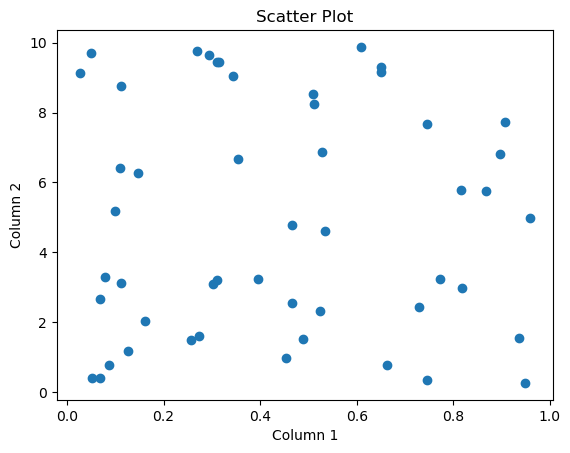

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Create a sample DataFrame
data = pd.DataFrame({
    "column1": np.random.rand(50),  # 50 random values for column1
    "column2": np.random.rand(50) * 10  # 50 random values (multiplied by 10) for column2
})

# Display the first few rows
print(data.head())

# Create a scatter plot
plt.scatter(data["column1"], data["column2"])
plt.xlabel("Column 1")
plt.ylabel("Column 2")
plt.title("Scatter Plot")
plt.show()

In [7]:
import pandas as pd 

data = pd.read_csv("./demo_dataset.csv")

In [8]:
print(data.head())

   log_id       source_ip destination_port protocol bytes_transferred  \
0      10      10.0.0.100      STRING_PORT      FTP              4096   
1      12  172.16.254.100              110     POP3          NEGATIVE   
2      27  172.16.254.200              110     POP3       NON_NUMERIC   
3       1   192.168.1.100               80     HTTP              1024   
4       2    192.168.1.81               53      TLS              9765   

  threat_level  
0            ?  
1            1  
2            1  
3            0  
4            0  


In [9]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   log_id             100 non-null    int64 
 1   source_ip          99 non-null     object
 2   destination_port   99 non-null     object
 3   protocol           100 non-null    object
 4   bytes_transferred  100 non-null    object
 5   threat_level       100 non-null    object
dtypes: int64(1), object(5)
memory usage: 4.8+ KB
None


In [10]:
# finding the missing values 
print(data.isnull().sum())

log_id               0
source_ip            1
destination_port     1
protocol             0
bytes_transferred    0
threat_level         0
dtype: int64


In [11]:
import re

def is_valid_ip(ip):
    pattern = re.compile(r'^((25[0-5]|2[0-4][0-9]|[01]?[0-9][0-9]?)\.){3}(25[0-5]|2[0-4][0-9]|[01]?[0-9][0-9]?)$')
    return bool(pattern.match(ip))

# Check for invalid IP addresses
invalid_ips = data[~data['source_ip'].astype(str).apply(is_valid_ip)]
print(invalid_ips)

    log_id       source_ip destination_port protocol bytes_transferred  \
40      41      10.0.0.300               25     SMTP              4096   
51      52    10.10.10.450      STRING_PORT      FTP              4096   
55      56             NaN               53      DNS              1024   
57      58   192.168.1.475              NaN      UDP              2048   
63      64      MISSING_IP               53      DNS              1024   
65      66   192.168.1.600      UNUSED_PORT      UDP              2048   
71      72      MISSING_IP               53      DNS              1024   
74      75    172.16.1.400               80     HTTP              1024   
82      83    172.16.1.450               80     HTTP              1024   
87      88      MISSING_IP               53      DNS              1024   
88      89    10.10.10.700              443      TLS               512   
92      93      INVALID_IP              110     POP3              4096   
93      94  192.168.1.1050            

In [12]:
valid_protocols = ['TCP', 'TLS', 'SSH', 'POP3', 'DNS', 'HTTPS', 'SMTP', 'FTP', 'UDP', 'HTTP']

# Check for invalid protocol values
invalid_protocols = data[~data['protocol'].isin(valid_protocols)]
print(invalid_protocols)

    log_id      source_ip destination_port protocol bytes_transferred  \
30      31  192.168.1.119              443  UNKNOWN              9513   
80      81  192.168.1.224               25  UNKNOWN              1161   

   threat_level  
30            2  
80            1  


In [13]:
def is_valid_bytes(bytes):
    try:
        bytes = int(bytes)
        return bytes >= 0
    except ValueError:
        return False

# Check for invalid bytes transferred
invalid_bytes = data[~data['bytes_transferred'].apply(is_valid_bytes)]
print(invalid_bytes)

    log_id       source_ip destination_port protocol bytes_transferred  \
1       12  172.16.254.100              110     POP3          NEGATIVE   
2       27  172.16.254.200              110     POP3       NON_NUMERIC   
93      94  192.168.1.1050               53      DNS       NON_NUMERIC   

   threat_level  
1             1  
2             1  
93            0  


In [14]:
def is_valid_threat_level(threat_level):
    try:
        threat_level = int(threat_level)
        return 0 <= threat_level <= 2
    except ValueError:
        return False

# Check for invalid threat levels
invalid_threat_levels = data[~data['threat_level'].apply(is_valid_threat_level)]
print(invalid_threat_levels)

    log_id      source_ip destination_port protocol bytes_transferred  \
0       10     10.0.0.100      STRING_PORT      FTP              4096   
34      35  192.168.1.200      STRING_PORT      FTP              4096   
51      52   10.10.10.450      STRING_PORT      FTP              4096   
67      68    10.10.10.77      STRING_PORT      FTP              4096   

   threat_level  
0             ?  
34            ?  
51            ?  
67            ?  


In [19]:
import pandas as pd
import numpy as np
import re
from ipaddress import ip_address

df = pd.read_csv('demo_dataset.csv')

invalid_ips = ['INVALID_IP', 'MISSING_IP']
invalid_ports = ['STRING_PORT', 'UNUSED_PORT']
invalid_bytes = ['NON_NUMERIC', 'NEGATIVE']
invalid_threat = ['?']

df.replace(invalid_ips + invalid_ports + invalid_bytes + invalid_threat, np.nan, inplace=True)

df['destination_port'] = pd.to_numeric(df['destination_port'], errors='coerce')
df['bytes_transferred'] = pd.to_numeric(df['bytes_transferred'], errors='coerce')
df['threat_level'] = pd.to_numeric(df['threat_level'], errors='coerce')

def is_valid_ip(ip):
    pattern = re.compile(r'^((25[0-5]|2[0-4][0-9]|[01]?\d?\d)\.){3}(25[0-5]|2[0-4]\d|[01]?\d?\d)$')
    if pd.isna(ip) or not pattern.match(str(ip)):
        return np.nan
    return ip

df['source_ip'] = df['source_ip'].apply(is_valid_ip)


In [21]:
print(data.head())

   log_id       source_ip destination_port protocol bytes_transferred  \
0      10      10.0.0.100      STRING_PORT      FTP              4096   
1      12  172.16.254.100              110     POP3          NEGATIVE   
2      27  172.16.254.200              110     POP3       NON_NUMERIC   
3       1   192.168.1.100               80     HTTP              1024   
4       2    192.168.1.81               53      TLS              9765   

  threat_level  
0            ?  
1            1  
2            1  
3            0  
4            0  


In [22]:
from sklearn.impute import SimpleImputer

numeric_cols = ['destination_port', 'bytes_transferred', 'threat_level']
categorical_cols = ['protocol']

num_imputer = SimpleImputer(strategy='median')
df[numeric_cols] = num_imputer.fit_transform(df[numeric_cols])

cat_imputer = SimpleImputer(strategy='most_frequent')
df[categorical_cols] = cat_imputer.fit_transform(df[categorical_cols])


In [23]:
from sklearn.impute import KNNImputer

knn_imputer = KNNImputer(n_neighbors=5)
df[numeric_cols] = knn_imputer.fit_transform(df[numeric_cols])


In [25]:

valid_protocols = ['TCP', 'TLS', 'SSH', 'POP3', 'DNS', 'HTTPS', 'SMTP', 'FTP', 'UDP', 'HTTP']
df.loc[~df['protocol'].isin(valid_protocols), 'protocol'] = df['protocol'].mode()[0]

df['source_ip'] = df['source_ip'].fillna('0.0.0.0')
df['destination_port'] = df['destination_port'].clip(lower=0, upper=65535)


In [27]:
print(data.head())

   log_id       source_ip destination_port protocol bytes_transferred  \
0      10      10.0.0.100      STRING_PORT      FTP              4096   
1      12  172.16.254.100              110     POP3          NEGATIVE   
2      27  172.16.254.200              110     POP3       NON_NUMERIC   
3       1   192.168.1.100               80     HTTP              1024   
4       2    192.168.1.81               53      TLS              9765   

  threat_level  
0            ?  
1            1  
2            1  
3            0  
4            0  


In [28]:
print(df.describe(include='all'))

            log_id source_ip  destination_port protocol  bytes_transferred  \
count   100.000000       100        100.000000      100          100.00000   
unique         NaN        76               NaN        9                NaN   
top            NaN   0.0.0.0               NaN     HTTP                NaN   
freq           NaN        15               NaN       27                NaN   
mean     50.500000       NaN        776.860000      NaN         4138.64000   
std      29.011492       NaN       6542.582099      NaN         2526.40978   
min       1.000000       NaN         22.000000      NaN          498.00000   
25%      25.750000       NaN         53.000000      NaN         1693.25000   
50%      50.500000       NaN         80.000000      NaN         4096.00000   
75%      75.250000       NaN        110.000000      NaN         5971.75000   
max     100.000000       NaN      65535.000000      NaN         9765.00000   

        threat_level  
count     100.000000  
unique           